In [71]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(os.path.abspath('..'))
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [72]:
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
#descargamos si no existen
utils.descarga("https://ignaciorlando.github.io/datasets/data-science/movies.csv", "movies.csv", "ej1")

No vamos a bajar el archivo porque ya existe


In [4]:
#leemos el archivo csv
df = pd.read_csv("movies.csv")

In [102]:
df.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9999 non-null   str    
 1   YEAR      9355 non-null   str    
 2   GENRE     9919 non-null   str    
 3   RATING    8179 non-null   float64
 4   ONE-LINE  8713 non-null   str    
 5   STARS     9999 non-null   str    
 6   VOTES     8179 non-null   str    
 7   RunTime   7041 non-null   float64
 8   Gross     460 non-null    str    
dtypes: float64(2), str(7)
memory usage: 703.2 KB


<p>Analizamos los posibles valores en la columna ONE-LINE.

In [7]:
df['ONE-LINE'].value_counts()

ONE-LINE
\nAdd a Plot\n                                                                                                                                                1265
\nThe Buddis bounce, spin, glide - and giggle. - through their magical world, learning new things and sharing the joy of friendship.                             8
\nWith kindness, curiosity and childlike wonder, five best friends explore their colourful world and find the extraordinary in everyday things.                  8
\nPlot unknown.                                                                                                                                                  7
\nPlot under wraps.                                                                                                                                              7
                                                                                                                                                              ... 
\nAfter getti

In [21]:
print(df[df['ONE-LINE'].str.contains('plot', case=False, na=False)]['ONE-LINE'])

105     \nSet in early 18th-century Madrid, the plot f...
117     \nA group of ambitious law students and their ...
175     \nDevoted lifeguard Mitch Buchannon butts head...
360     \nA conspiracy thriller that follows the journ...
500     \nAn evil high-fashion designer plots to steal...
886     \nAfter the death of his parents during World ...
1306    \nA rivalry between big cat eccentrics takes a...
1548    \nThe bullied outcasts at prestigious Al Rawab...
1739    \nSet in the distant future where both North a...
1800                       \nThe plot is currently kept .
1994    \nWhen a young Bogotá-based detective gets dra...
2014    \nWorlds collide and lives shatter when Altagr...
2026    \nA recap of the first 24 episodes of Neon Gen...
2081    \nA year has passed since Guts parted ways wit...
2147    \nAfter an ambitious actor insinuates himself ...
2211    \nA disgraced black ops agent is dispatched to...
2317    \nTired of being locked in a reptile house whe...
2600    \nFocu

In [20]:
df['ONE-LINE'].isna().sum()

np.int64(1286)

<p>Reemplazamos todos los valores que coincidan con lo dado por nulo.

In [19]:
df['ONE-LINE'] = df['ONE-LINE'].replace(['\nAdd a Plot\n', '\nPlot unknown.', '\nPlot under wraps.', '\nPlot kept under wraps.', ''], pd.NA)

In [17]:
df['ONE-LINE'] = df['ONE-LINE'].str.replace('\nPlot unknown. ', '', regex=False)
df['ONE-LINE'] = df['ONE-LINE'].str.replace('\nPlot Unknown, ', '', regex=False)
df['ONE-LINE'] = df['ONE-LINE'].str.replace('\nPlot Unknown. ', '', regex=False)
df['ONE-LINE'] = df['ONE-LINE'].str.replace('\nPlot Unknown.', '', regex=False)
df['ONE-LINE'] = df['ONE-LINE'].str.replace('\nThe plot is unknown', '', regex=False)
df['ONE-LINE'] = df['ONE-LINE'].str.replace('\nPlot details are', '', regex=False)

In [ ]:
for idx, val in df["ONE-LINE"].value_counts().items():
  print(idx, val)

In [190]:
df = pd.read_csv("movies.csv")

GENRE

<p>Realizamos una copia del dataset

In [27]:
pre_df_d = df.copy()

pre_df_d.isna().sum()

MOVIES         0
YEAR         644
GENRE         80
RATING      1820
ONE-LINE    1286
STARS          0
VOTES       1820
RunTime     2958
Gross       9539
dtype: int64

In [30]:
df['GENRE'].value_counts()


GENRE
\nComedy                                      852
\nAnimation, Action, Adventure                693
\nDrama                                       562
\nDocumentary                                 498
\nCrime, Drama, Mystery                       336
                                             ... 
\nDocumentary, Action, Crime                    1
\nShort, History                                1
\nShort, Reality-TV                             1
\nShort, Action                                 1
\nNews, Reality-TV                              1
Name: count, Length: 510, dtype: int64

In [32]:
print(df[df['GENRE'].str.contains('Unknown', case=False, na=False)]['GENRE'])

Series([], Name: GENRE, dtype: str)


In [33]:
genre_clean = pre_df_d['GENRE'].str.strip() #eliminamos espacios en blanco y tabulaciones
genre_clean = genre_clean.str.get_dummies(sep=', ') #creamos nuevas columnas binarias por cada valor.
pre_df_d = pre_df_d.join(genre_clean) #unimos al dataset esas columnas

In [ ]:
pre_df_d.head()

- Una misma obra cinematográfica puede pertenecer a múltiples géneros simultáneamente (por ejemplo, Acción, Comedia y Drama).
-  Usamos One-Hot Encoding (str.get_dummies) porque es el mejor mecanismo para conservar la estructura del dataset original (donde 1 fila representa 1 película). Permite evaluar la presencia de cada género como una variable binaria ($1$ o $0$) sin imponer un orden artificial entre ellos ni distorsionar la cardinalidad del conjunto.  Alternativa y su limitación (explode): Desanidar las listas con .explode() duplicaría las filas por cada género que tenga una película. Aunque explode() es útil para gráficos de frecuencia o agregaciones simples por género, altera la unidad de observación y provocaría sobreconteo en análisis estadísticos o en modelos de machine learning. Por eso, One-Hot Encoding es la mejor opción de preprocesamiento general.

<h3>Inciso E

<span style="color:orange">Existe el preconcepto de que las mejores películas según el público son las que han logrado mejores recaudaciones. ¿Qué podés decirnos de esta hipótesis, considerando los datos disponibles? Justificar.</span>

In [48]:
pre_df_e = pre_df_d.copy()

In [51]:
df['RATING'].isna().sum()

np.int64(1820)

In [ ]:
#convertimos a numerico
pre_df_e['Gross'] = (
    df['Gross']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace('M', '', regex=False)
    .str.strip()
)

pre_df_e['Gross'] = pd.to_numeric(pre_df_e['Gross'], errors='coerce')

pre_df_e = pre_df_e.dropna(subset=['RATING', 'Gross'])


In [50]:
pre_df_e.info()

<class 'pandas.DataFrame'>
Index: 460 entries, 77 to 6292
Data columns (total 36 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MOVIES       460 non-null    str    
 1   YEAR         460 non-null    str    
 2   GENRE        460 non-null    str    
 3   RATING       460 non-null    float64
 4   ONE-LINE     460 non-null    str    
 5   STARS        460 non-null    str    
 6   VOTES        460 non-null    str    
 7   RunTime      460 non-null    float64
 8   Gross        460 non-null    float64
 9   Action       460 non-null    int64  
 10  Adventure    460 non-null    int64  
 11  Animation    460 non-null    int64  
 12  Biography    460 non-null    int64  
 13  Comedy       460 non-null    int64  
 14  Crime        460 non-null    int64  
 15  Documentary  460 non-null    int64  
 16  Drama        460 non-null    int64  
 17  Family       460 non-null    int64  
 18  Fantasy      460 non-null    int64  
 19  Film-Noir    460 non-n

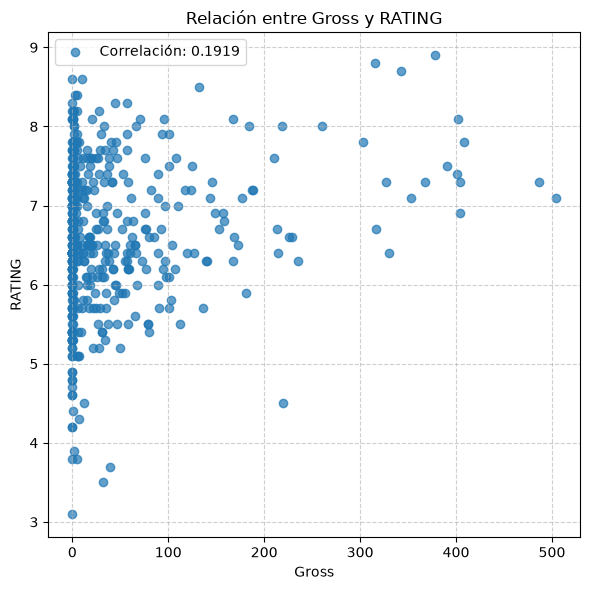

In [52]:
utils.scatter_plot('Gross', 'RATING', pre_df_e)

<p>No hay argumentos suficientes para decir que las mejores peliculas son las que han logrado mejores recaudaciones.

<h3>Inciso f

In [56]:
pre_df_f = df.copy()

In [57]:
pre_df_f.info()

<class 'pandas.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9999 non-null   str    
 1   YEAR      9355 non-null   str    
 2   GENRE     9919 non-null   str    
 3   RATING    8179 non-null   float64
 4   ONE-LINE  8713 non-null   str    
 5   STARS     9999 non-null   str    
 6   VOTES     8179 non-null   str    
 7   RunTime   7041 non-null   float64
 8   Gross     460 non-null    str    
dtypes: float64(2), str(7)
memory usage: 703.2 KB


In [ ]:
# pre_df_f['type'] = np.where (

#     pre_df_f['YEAR'].str.contains('–'),
#     'S',
#     'M'
# )
#pre_df_f = pre_df_f.dropna(subset=['RunTime', 'YEAR'])

In [58]:
from pyparsing import Regex

pre_df_f = pre_df_f.dropna(subset=['RunTime', 'YEAR']) #eliminamos filas con algun valor de esos nulo.

#creamos una nueva columna con el anio solo.
pre_df_f['YEAR_init'] = (
    pre_df_f['YEAR']
    .str.split('–')
    .str[0]
    .replace(r'\D', '', regex=True) #reemplaza todo lo que no sea digito por vacio
)
pre_df_f['YEAR_init'] = pd.to_numeric(pre_df_f['YEAR_init'])

#lambda, USAR!!!!
pre_df_f['type'] = pre_df_f['YEAR'].apply(lambda x: 'S' if '–' in str(x) else 'M')

#pre_df_f['YEAR_init'].value_counts()

In [ ]:
pre_df_f.head()

In [60]:
pre_df_f.info()

<class 'pandas.DataFrame'>
Index: 7013 entries, 0 to 9976
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MOVIES     7013 non-null   str    
 1   YEAR       7013 non-null   str    
 2   GENRE      7005 non-null   str    
 3   RATING     6786 non-null   float64
 4   ONE-LINE   6810 non-null   str    
 5   STARS      7013 non-null   str    
 6   VOTES      6786 non-null   str    
 7   RunTime    7013 non-null   float64
 8   Gross      460 non-null    str    
 9   YEAR_init  7011 non-null   float64
 10  type       7013 non-null   str    
dtypes: float64(3), str(8)
memory usage: 657.5 KB


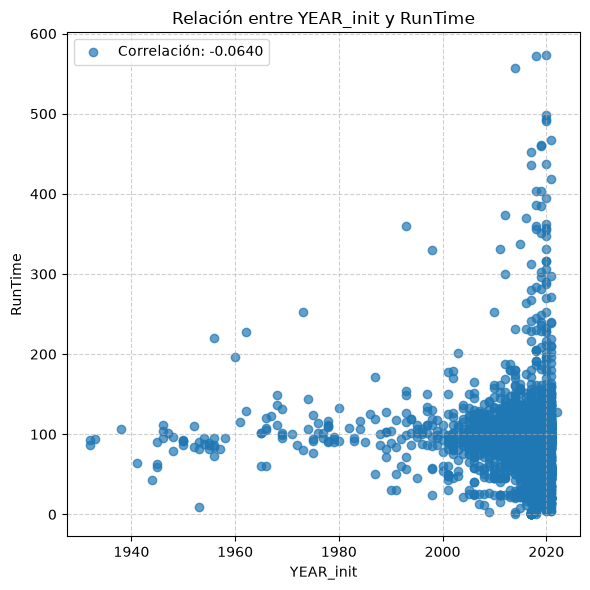

In [87]:
#observamos la relaicon entre el anio de inicio y la duracion en peliculas
pre_pelis = pre_df_f[pre_df_f['type'] == 'M']
utils.scatter_plot('YEAR_init', 'RunTime', pre_pelis)

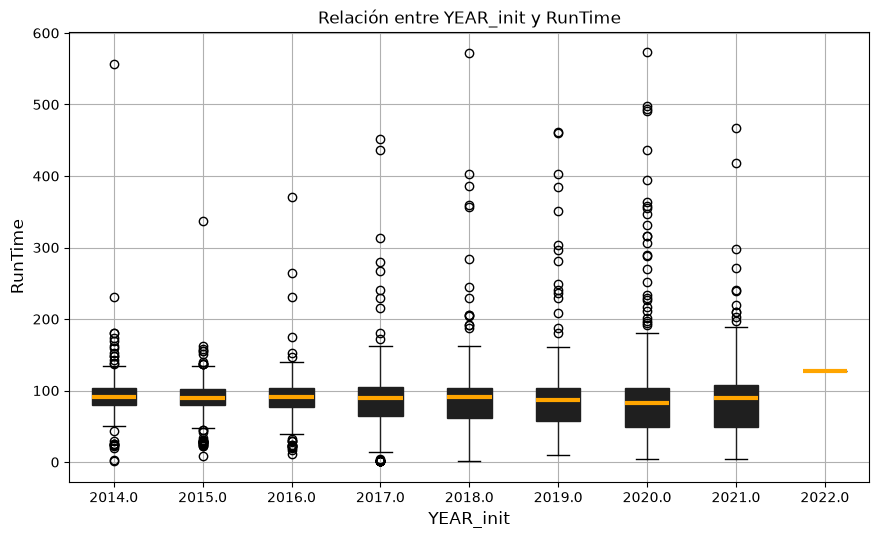

In [89]:
utils.box_plot('YEAR_init', 'RunTime', pre_df_f[(pre_df_f['type'] == 'M') & (pre_df_f['YEAR_init'] >= 2014)])

C:\Users\Tomas\AppData\Local\Temp\ipykernel_7572\2699230852.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  utils.tendencia_temporal('YEAR_init', 'RunTime', pre_pelis[pre_df_f['YEAR_init'] >= 2011])


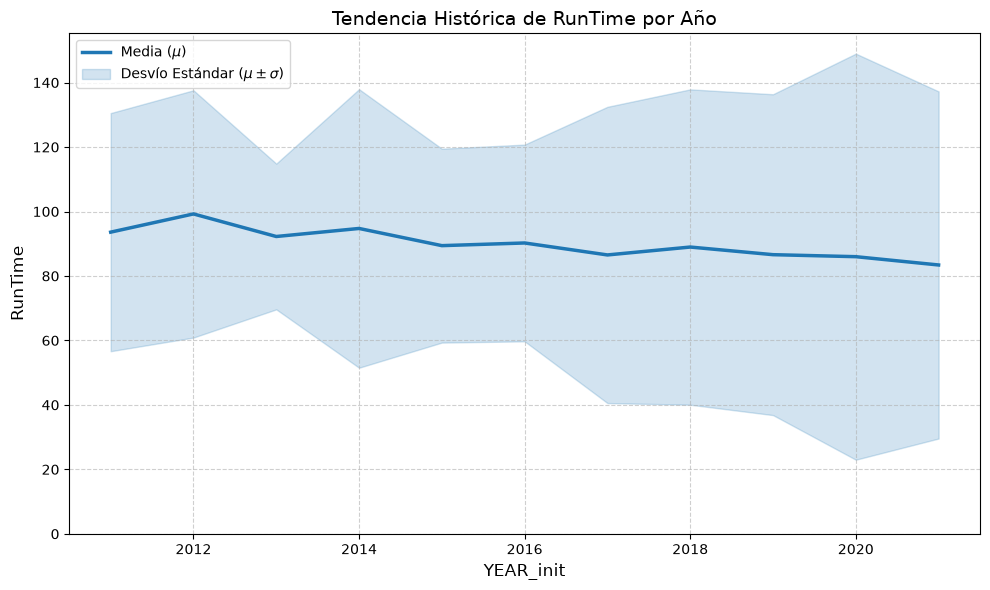

Mediana 2016: 91.0
Mediana 2017: 90.0
Mediana 2018: 91.0
Mediana 2019: 87.0
Mediana 2020: 82.0
Mediana 2021: 89.0
Mediana 2022: 128.0


In [101]:
utils.tendencia_temporal('YEAR_init', 'RunTime', pre_pelis[pre_df_f['YEAR_init'] >= 2011])
for i in range(2016, 2023):
    print(f'Mediana {i}: {pre_pelis[pre_pelis['YEAR_init'] == i]['RunTime'].median()}')

<p>Como podemos ver es falso, debido a que practicamente se mantuvo igual el tiempo de duracion en los ultimos anios

Median 90.0


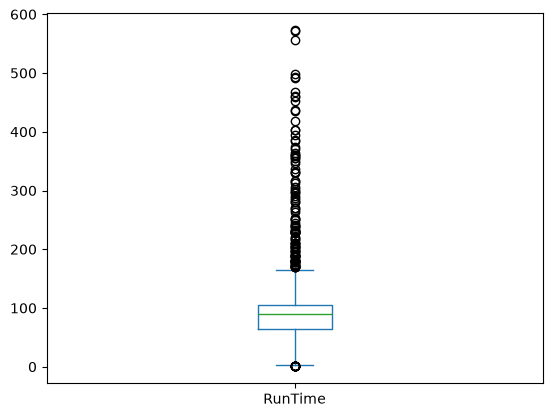

In [90]:
pre_pelis['RunTime'].plot.box()
print(f'Median {pre_pelis['RunTime'].median()}')

In [91]:
median = pre_pelis[pre_pelis['YEAR_init'] == 2020]['RunTime'].median()
median

np.float64(82.0)

<Axes: >

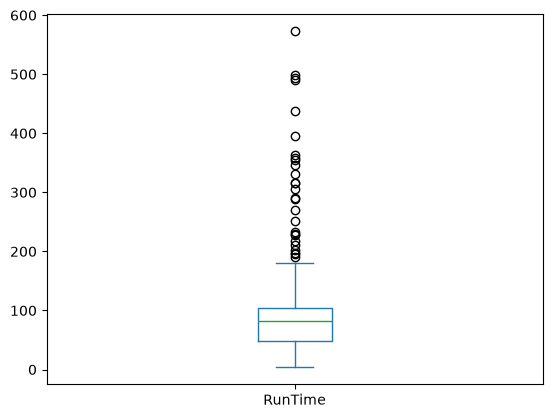

In [188]:
pre_pelis[pre_pelis['YEAR_init'] == 2020]['RunTime'].plot.box()

<p>Preguntar si estaba bien dividir entre peliculas y series

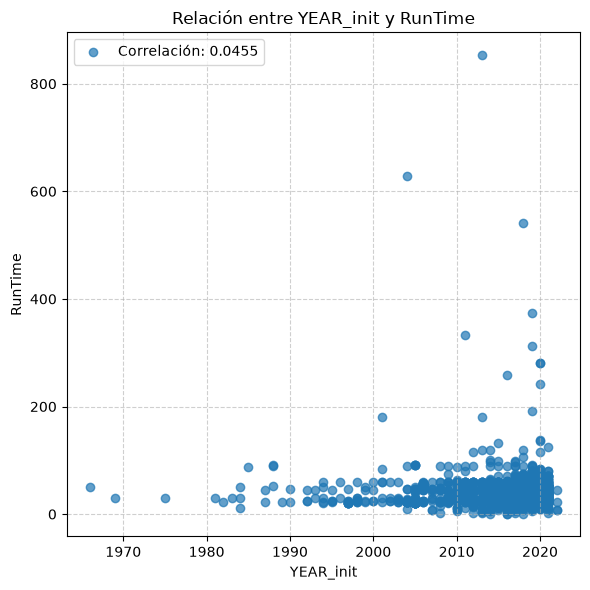

In [183]:
pre_series = pre_df_f[pre_df_f['type'] == 'S']
utils.scatter_plot('YEAR_init', 'RunTime', pre_series)

<h3>Inciso G

<span style="color:orange"> El crecimiento de produccion de peliculas en los ultimos 6 anios fue mayor que el de las series </span>

In [151]:
pre_df_g = pre_df_f.copy()

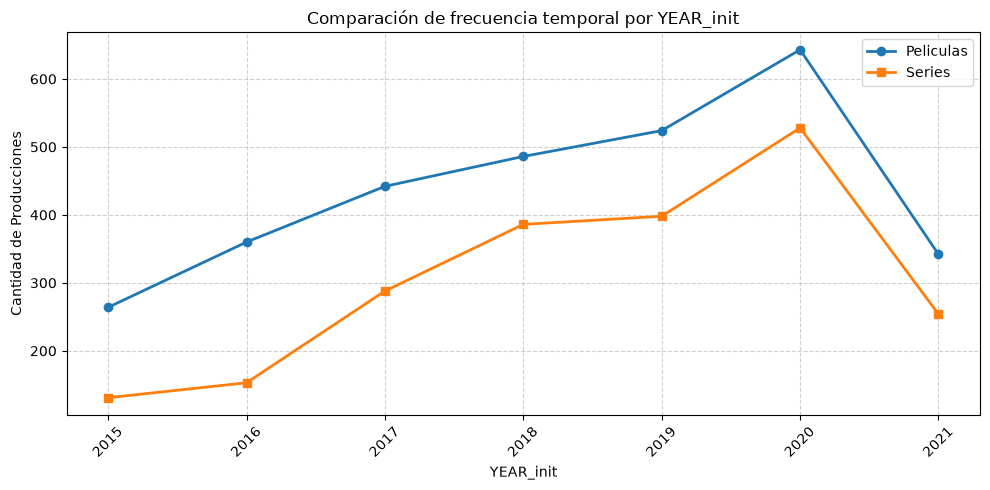

El crecimiento anual compuesto de las peliculas en los ultimos 6 anios fue del 4.41%
El crecimiento anual compuesto de las series en los ultimos 6 anios fue del 11.67%


In [ ]:
pre = pre_df_g[(pre_df_g['YEAR_init'] >= 2015) & (pre_df_g['YEAR_init'] <= 2021) & (pre_df_g['type'] == 'M')]
pre2 = pre_df_g[(pre_df_g['YEAR_init'] >= 2015) & (pre_df_g['YEAR_init'] <= 2021) & (pre_df_g['type'] == 'S')]
#frecuencias de peliculas y series a lo largo del 2015 hasta el 2021
utils.linea_comparativa('YEAR_init', pre, pre2, 'Peliculas', 'Series')
frec1 = pre_df_g[(pre_df_g['YEAR_init'] >= 2015) &  (pre_df_g['YEAR_init'] <= 2021) & (pre_df_g['type'] == 'M')].groupby('YEAR_init').size()
frec2 = pre_df_g[(pre_df_g['YEAR_init'] >= 2015) &  (pre_df_g['YEAR_init'] <= 2021) & (pre_df_g['type'] == 'S')].groupby('YEAR_init').size()

frec_inicial = frec1.iloc[0]
frec_final = frec1.iloc[-1]
per = len(frec1) - 1

cagr = (frec_final / frec_inicial) ** (1/per) - 1
print(f"El crecimiento anual compuesto de las peliculas en los ultimos 6 anios fue del {round(cagr * 100, 2)}%")

frec_inicial = frec2.iloc[0]
frec_final = frec2.iloc[-1]
per = len(frec2) - 1

cagr = (frec_final / frec_inicial) ** (1/per) - 1
print(f"El crecimiento anual compuesto de las series en los ultimos 6 anios fue del {round(cagr * 100, 2)}%")

#print(frec1.pct_change() * 100)

<p>Extra que quedo

In [ ]:
pre_df_f['Genre']

In [114]:
#utils.barras_binarias(['Action', 'Comedy', 'Drama', 'Horror', 'Sci-Fi'], pre_df_f)
pre_g = pre_df_f.groupby('type')['RATING'].median()
pre_g

type
M    6.5
S    7.6
Name: RATING, dtype: float64

In [ ]:
pre_g = 
pre_gpre_df_f[pre_df_f['type'] == 'M'].groupby('Thriller')['RATING'].median()

Thriller
0    6.6
1    5.9
Name: RATING, dtype: float64

In [245]:
pre_df_f['T_H'] = (pre_df_f['GENRE'].str.contains('Thriller')) | (pre_df_f['GENRE'].str.contains('Horror'))
# pre_g = pre_df_f[pre_df_f['YEAR_init'] >= 2020]
# pre_g = pre_g[pre_g['type'] == 'M'].groupby('T_H')['RATING'].median()
pre_g = pre_df_f[pre_df_f['type'] == 'M'].groupby('T_H')['RATING'].median()

pre_g

T_H
False    6.7
True     5.8
Name: RATING, dtype: float64

In [ ]:
pre_df_f.head()

In [ ]:
ff = pre_df_f[pre_df_f['YEAR_init'] == 2012]
ff